In [1]:
import pandas as pd
import os
os.chdir('..')

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np


In [3]:
df = pd.read_pickle('data/df.pkl')
df = df.drop(df[df['year'] == 2016].index)

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- Identify leakage columns ---
leakage_cols = [col for col in df.columns if any(
    col.endswith(f"_{m}") for m in range(36,45)
)]
leakage_cols.extend([col for col in df.columns if col.endswith('length')])
leakage_cols.extend([col for col in df.columns if 'mcari2' in col])

# --- Define target and features ---
target_cols = [
    'ndvi_smooth_mean_36',
    'ndvi_smooth_mean_37',
    'ndvi_smooth_mean_38',
    'ndvi_smooth_mean_39',
    'ndvi_smooth_mean_40',
    'ndvi_smooth_mean_41',
    'ndvi_smooth_mean_42',
    'ndvi_smooth_mean_43',
    
#     'ndwi_smooth_mean_36',
#     'ndwi_smooth_mean_37',
#     'ndwi_smooth_mean_38',
#     'ndwi_smooth_mean_39',
#     'ndwi_smooth_mean_40',
#     'ndwi_smooth_mean_41',
#     'ndwi_smooth_mean_42',
#     'ndwi_smooth_mean_43',

#     'evi_smooth_mean_36',
#     'evi_smooth_mean_37',
#     'evi_smooth_mean_38',
#     'evi_smooth_mean_39',
#     'evi_smooth_mean_40',
#     'evi_smooth_mean_41',
#     'evi_smooth_mean_42',
#     'evi_smooth_mean_43',
    
    'rendvi_smooth_mean_36',
    'rendvi_smooth_mean_37',
    'rendvi_smooth_mean_38',
    'rendvi_smooth_mean_39',
    'rendvi_smooth_mean_40',
    'rendvi_smooth_mean_41',
    'rendvi_smooth_mean_42',
    'rendvi_smooth_mean_43',


]
X = df.drop(columns=leakage_cols + ['plot_id', 'year', 'geometry'] + target_cols)
y = df[target_cols]

In [5]:
# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# # --- Multi-output Random Forest ---
# rf_model = MultiOutputRegressor(RandomForestRegressor(
#     n_estimators=300, max_depth=10, random_state=42, n_jobs=-1
# ))

In [7]:
# # --- Cross-validation ---
# cv = KFold(n_splits=5, shuffle=True, random_state=42)
# cv_rmse = -cross_val_score(rf_model, X_train, y_train, 
#                            cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
# cv_r2 = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)

In [8]:
# print(f"Cross-validated RMSE (per fold): {cv_rmse}")
# print(f"Cross-validated RMSE mean: {cv_rmse.mean():.4f}")
# print(f"Cross-validated R² mean: {cv_r2.mean():.4f}")

In [9]:
# # --- Fit on full training set ---
# rf_model.fit(X_train, y_train)

# # --- Predict on test set ---
# y_pred = rf_model.predict(X_test)

In [10]:
# # --- Evaluate ---
# rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
# r2_test = r2_score(y_test, y_pred)
# print(f"Test RMSE: {rmse_test:.4f}")
# print(f"Test R²: {r2_test:.4f}")

In [11]:
# --------------------------
# Base models
# --------------------------
base_models = [
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=100, max_depth=8, random_state=42)),
    ('ridge', Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ])),
    ('lasso', Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01))
    ]))
]

# --------------------------
# Stacked regressor
# --------------------------
stacked_model = StackingRegressor(
    estimators=base_models,
    final_estimator=RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42),
    cv=5,
    passthrough=True,
    n_jobs=-1
)

multi_output_model = MultiOutputRegressor(stacked_model, n_jobs=-1)

In [12]:
# --------------------------
# Fit model
# --------------------------
multi_output_model.fit(X_train, y_train)

MultiOutputRegressor(estimator=StackingRegressor(cv=5,
                                                 estimators=[('rf',
                                                              RandomForestRegressor(max_depth=12,
                                                                                    n_estimators=200,
                                                                                    random_state=42)),
                                                             ('gb',
                                                              GradientBoostingRegressor(max_depth=8,
                                                                                        random_state=42)),
                                                             ('ridge',
                                                              Pipeline(steps=[('scaler',
                                                                               StandardScaler()),
                                        

In [13]:
# --------------------------
# Predict & evaluate
# --------------------------
y_pred = multi_output_model.predict(X_test)

In [14]:
y_pred

array([[0.22928575, 0.231203  , 0.22706019, ..., 0.13588039, 0.13809085,
        0.13188011],
       [0.56259175, 0.57276817, 0.56798819, ..., 0.32820313, 0.27695132,
        0.23498408],
       [0.43261567, 0.41855818, 0.40699477, ..., 0.23275323, 0.2188562 ,
        0.21847949],
       ...,
       [0.47634654, 0.47053054, 0.45797188, ..., 0.2578049 , 0.25471732,
        0.24509453],
       [0.60339105, 0.60199849, 0.59615908, ..., 0.34699523, 0.33556388,
        0.31366611],
       [0.34102091, 0.32708215, 0.32324836, ..., 0.17262576, 0.17247922,
        0.15919636]])

In [15]:
# Compute RMSE per target
rmse_per_target = np.sqrt(np.mean((y_test - y_pred)**2, axis=0))
r2_test = r2_score(y_test, y_pred)

for i, col in enumerate(y.columns):
    print(f"RMSE for {col}: {rmse_per_target[i]:.4f}")
print(f'R2: {r2_test:.4f}')

RMSE for ndvi_smooth_mean_36: 0.0096
RMSE for ndvi_smooth_mean_37: 0.0145
RMSE for ndvi_smooth_mean_38: 0.0183
RMSE for ndvi_smooth_mean_39: 0.0225
RMSE for ndvi_smooth_mean_40: 0.0281
RMSE for ndvi_smooth_mean_41: 0.0329
RMSE for ndvi_smooth_mean_42: 0.0338
RMSE for ndvi_smooth_mean_43: 0.0346
RMSE for rendvi_smooth_mean_36: 0.0080
RMSE for rendvi_smooth_mean_37: 0.0111
RMSE for rendvi_smooth_mean_38: 0.0139
RMSE for rendvi_smooth_mean_39: 0.0173
RMSE for rendvi_smooth_mean_40: 0.0215
RMSE for rendvi_smooth_mean_41: 0.0242
RMSE for rendvi_smooth_mean_42: 0.0254
RMSE for rendvi_smooth_mean_43: 0.0237
R2: 0.9034


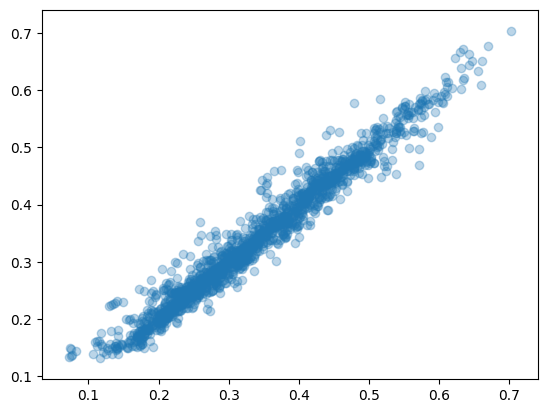

In [19]:
plt.scatter(y_test,y_pred, alpha = 0.3)
plt.plot(y_pre)

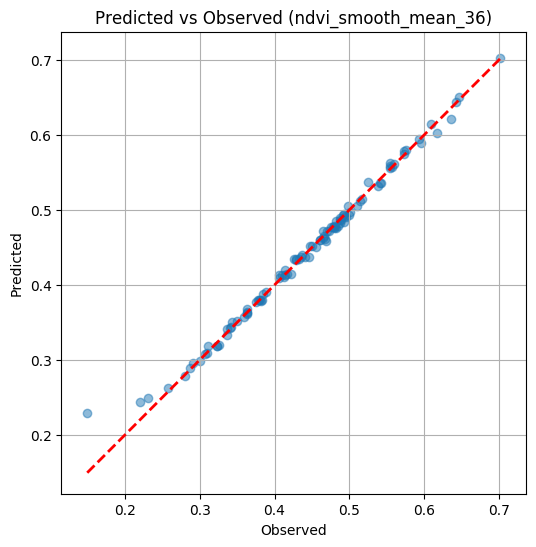

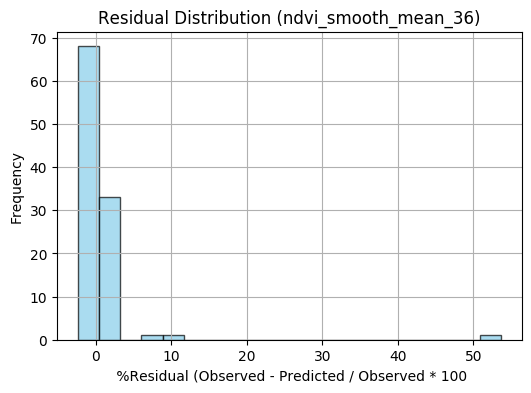

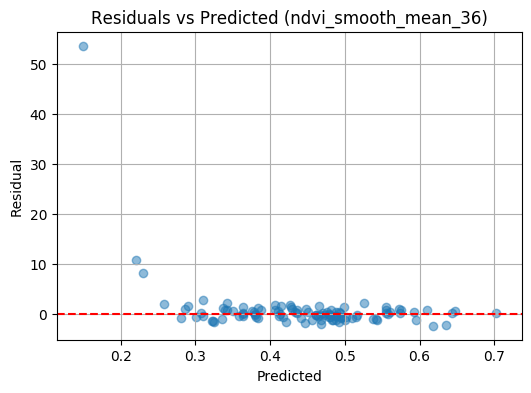

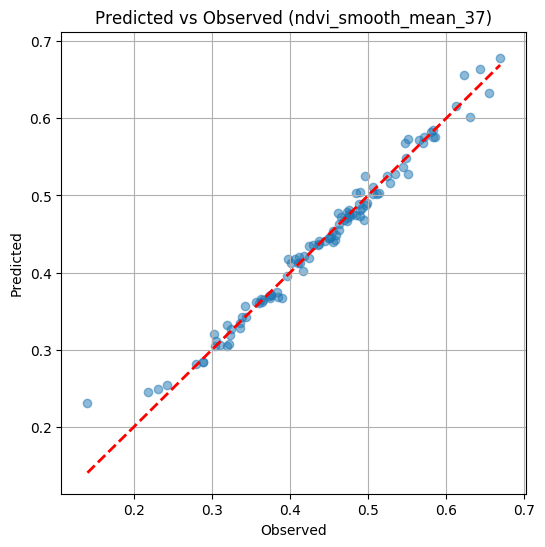

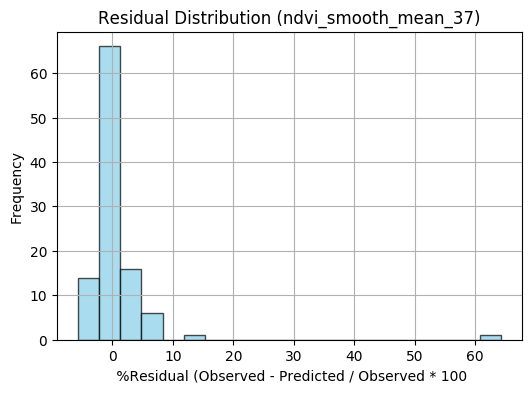

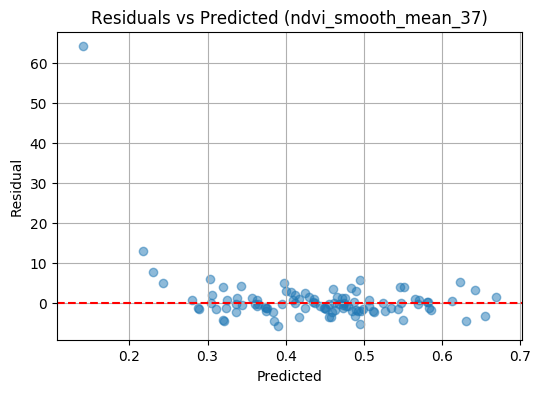

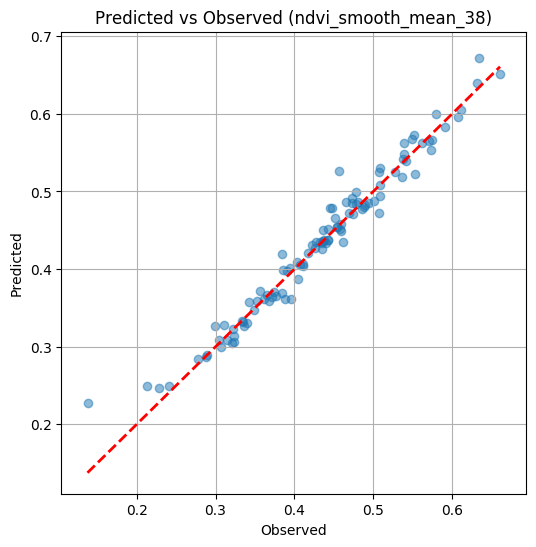

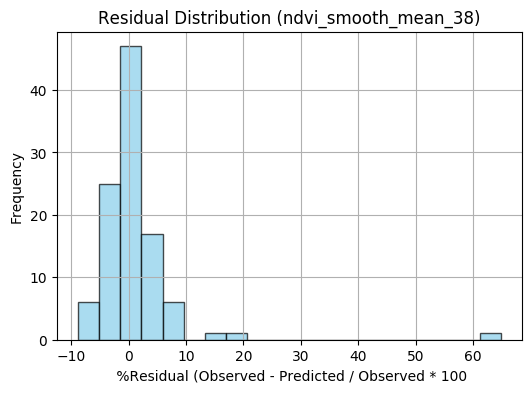

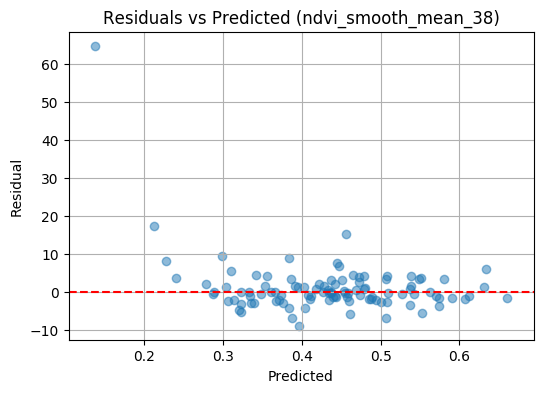

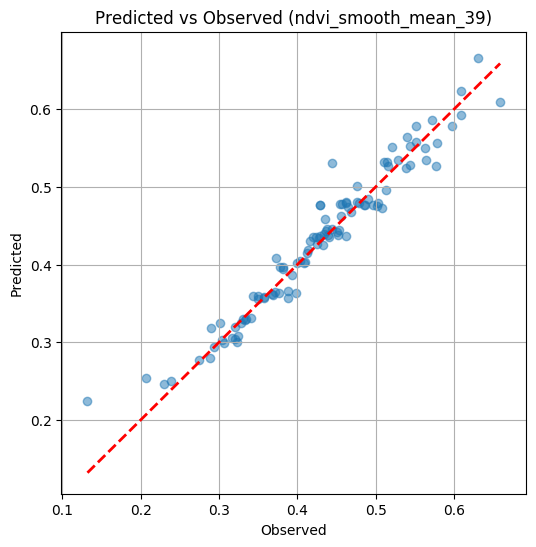

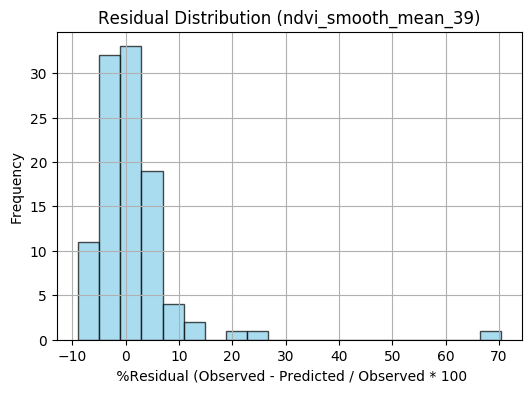

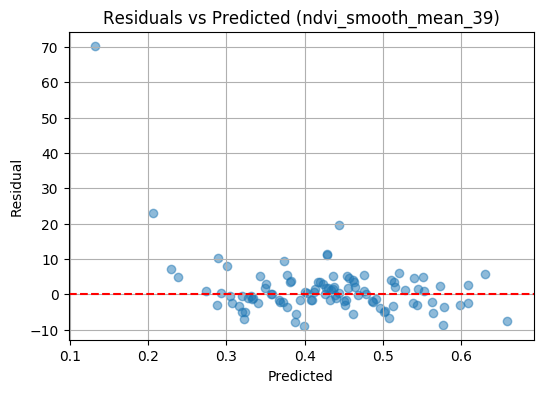

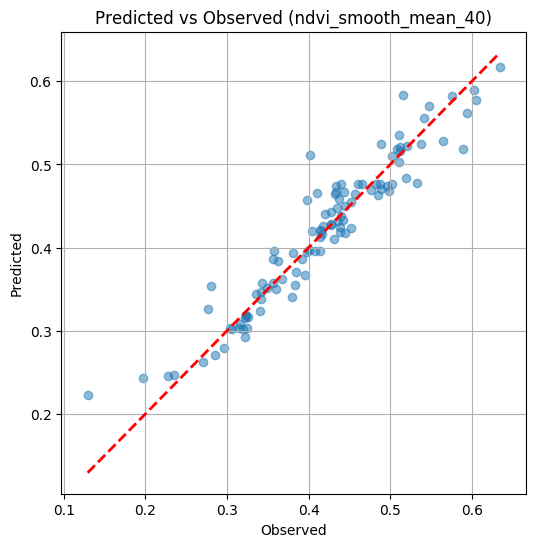

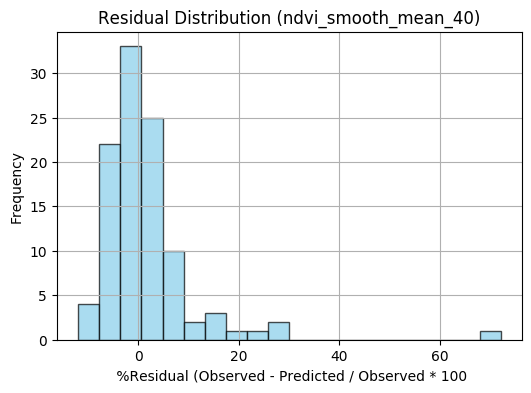

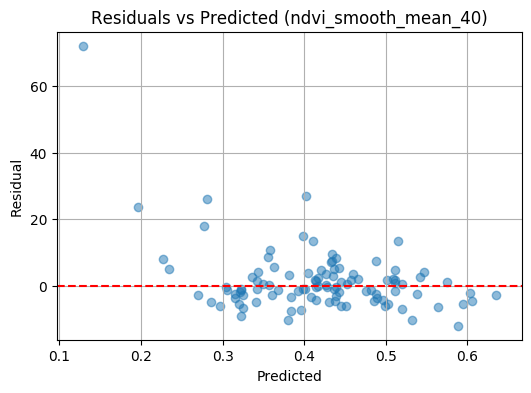

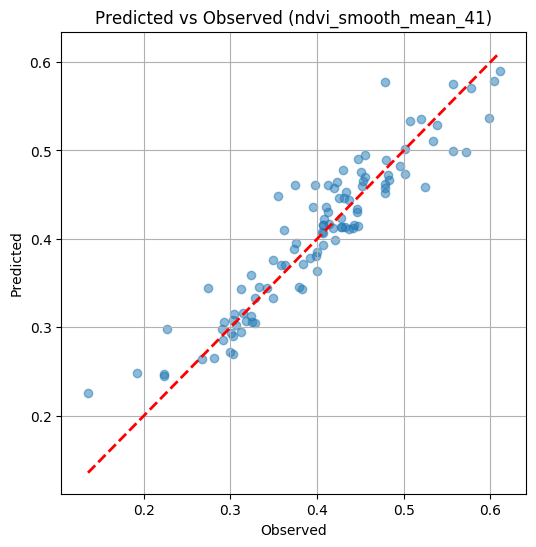

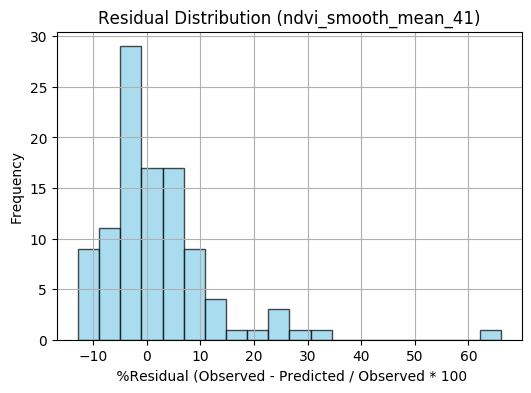

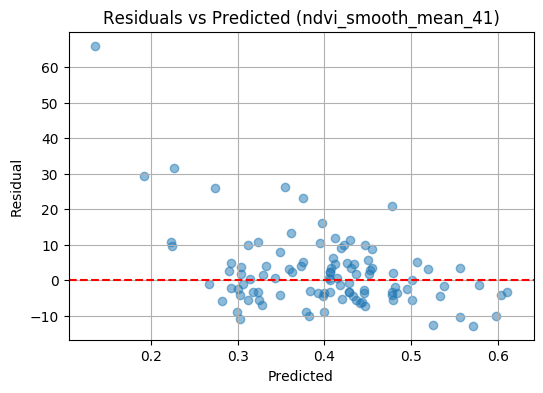

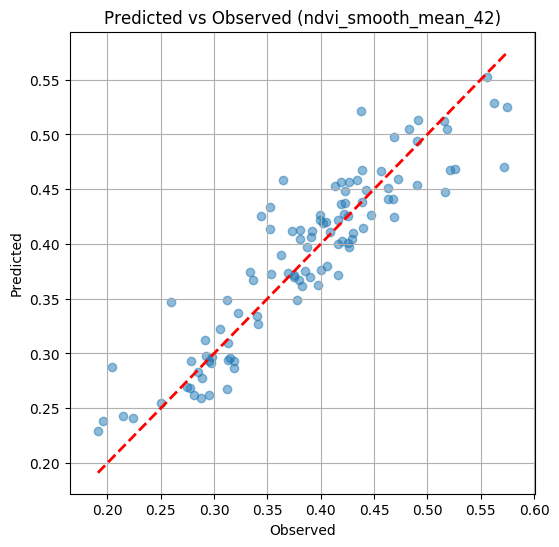

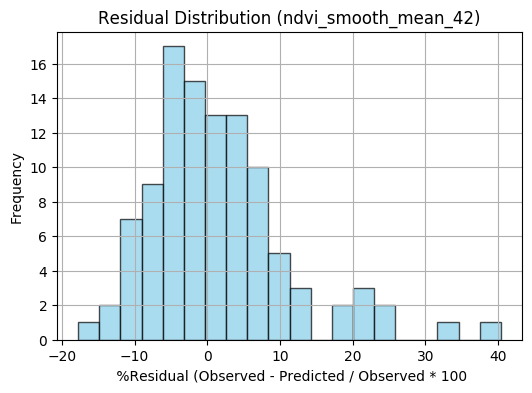

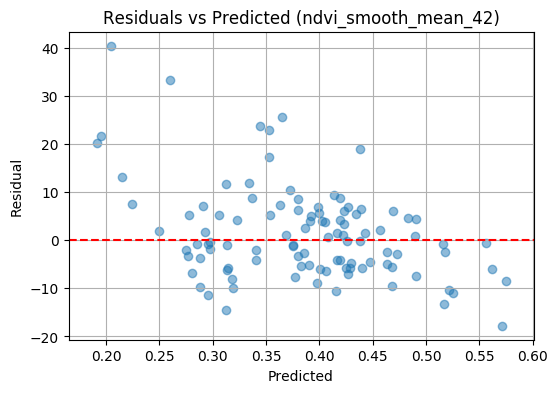

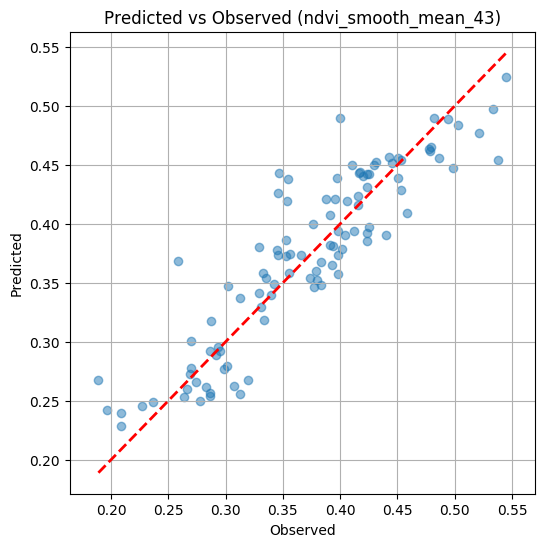

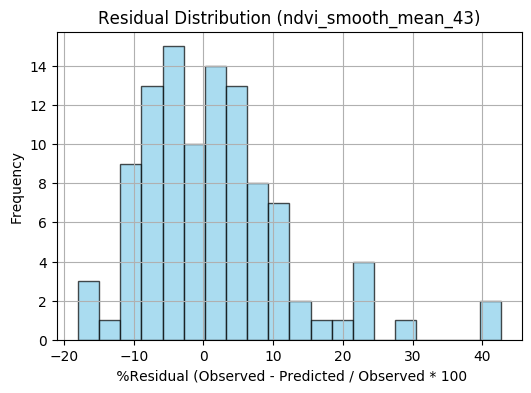

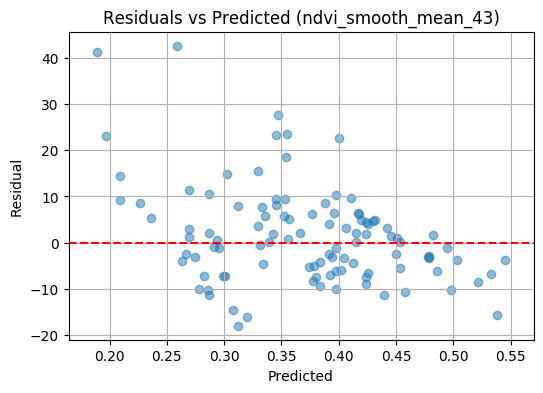

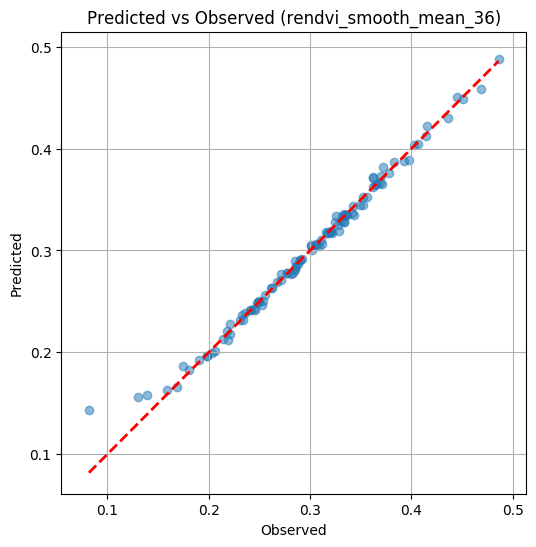

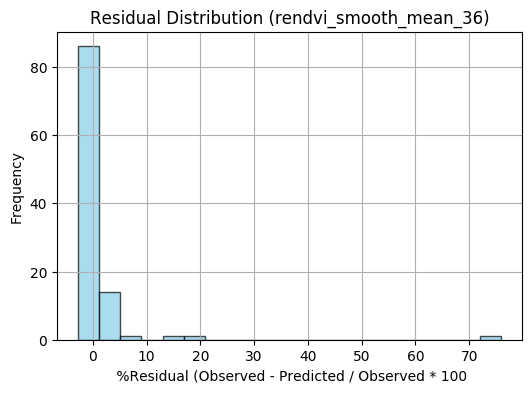

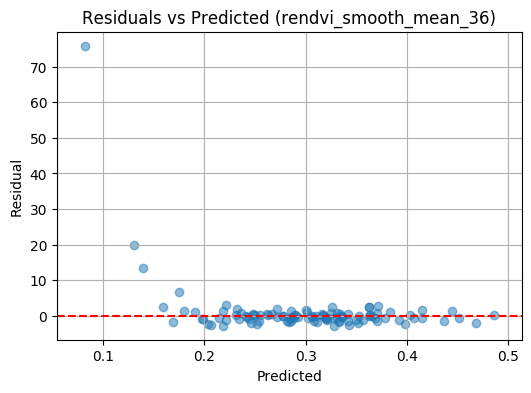

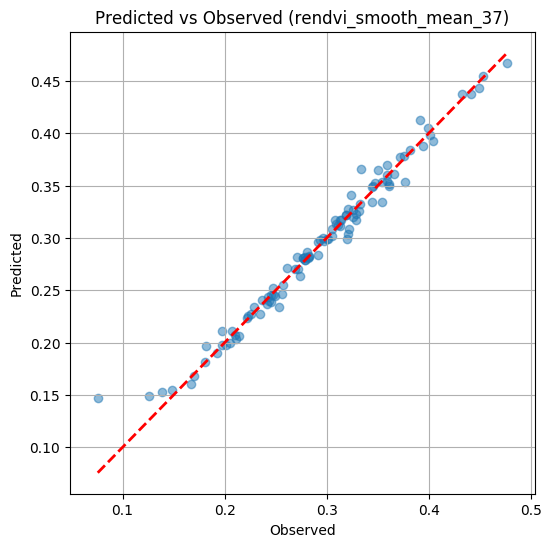

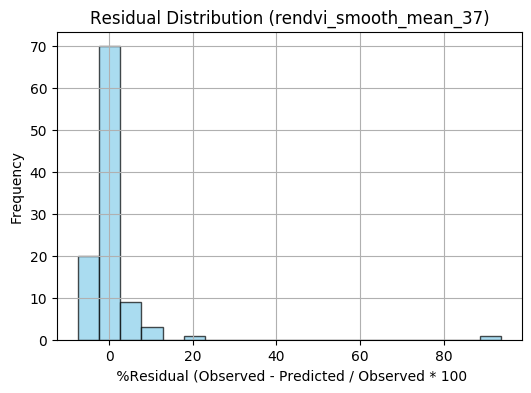

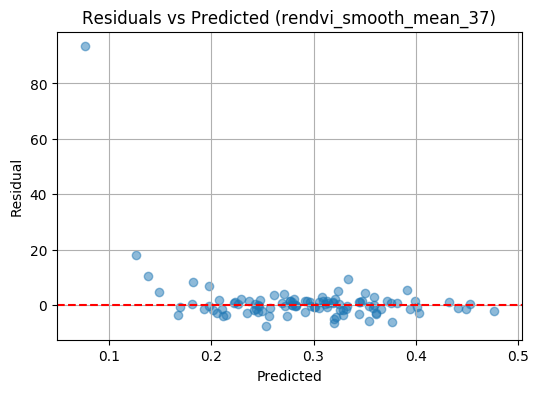

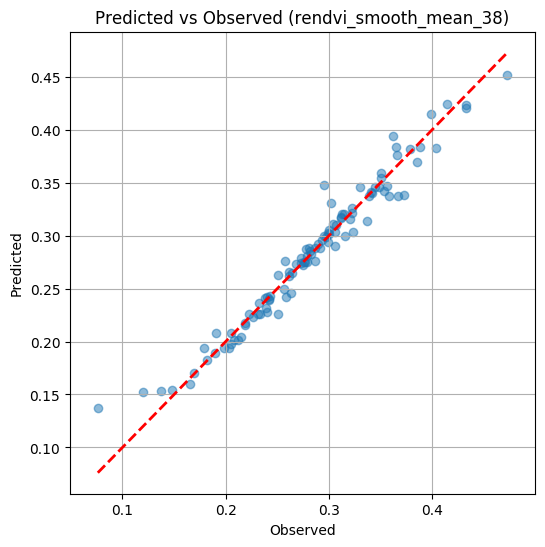

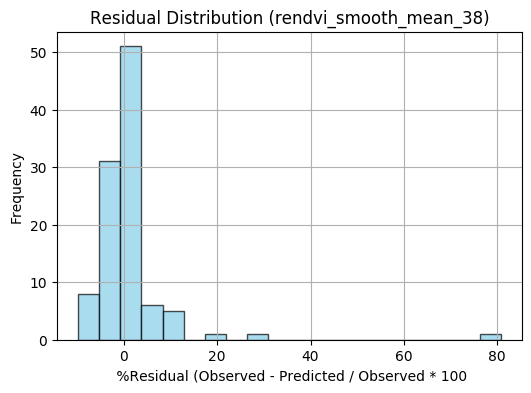

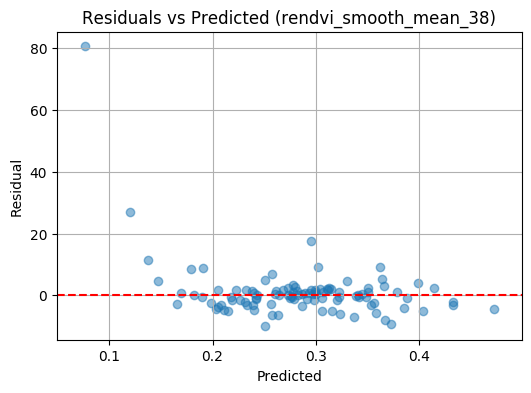

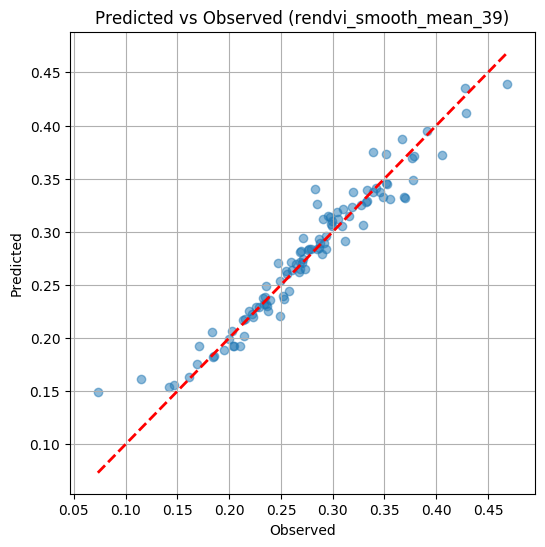

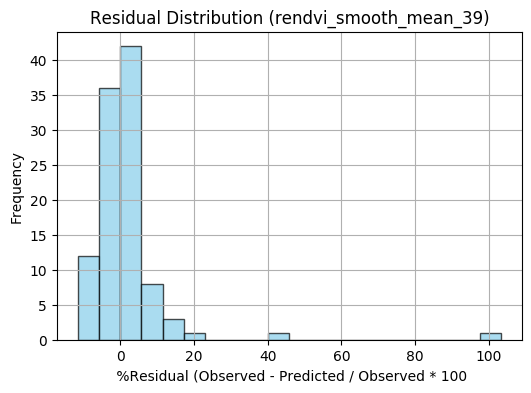

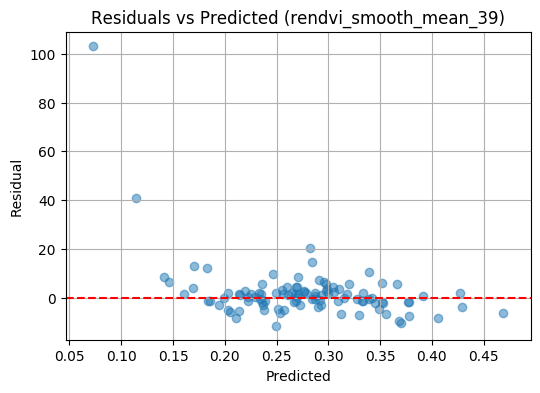

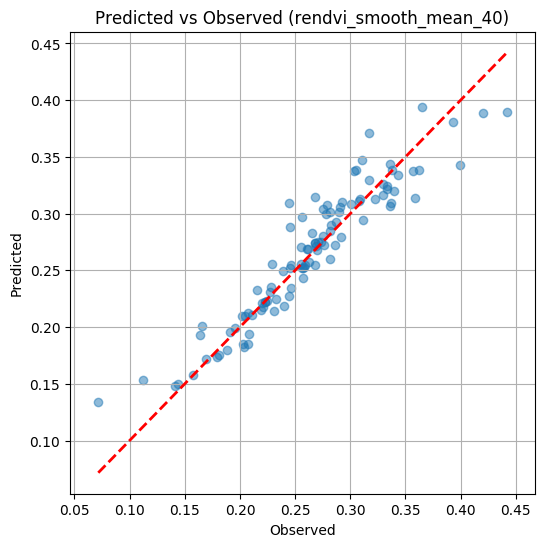

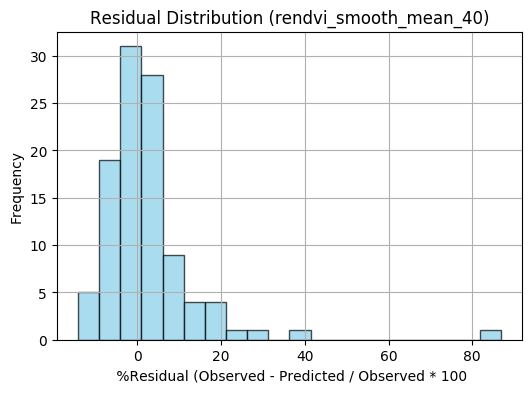

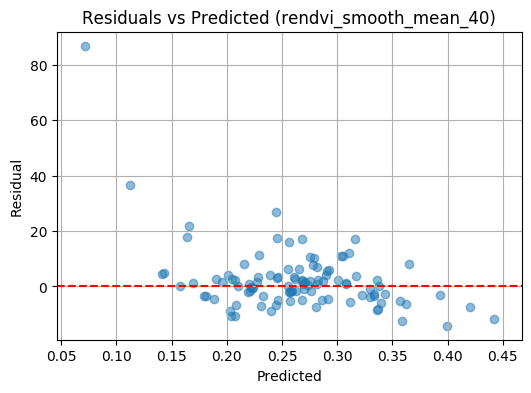

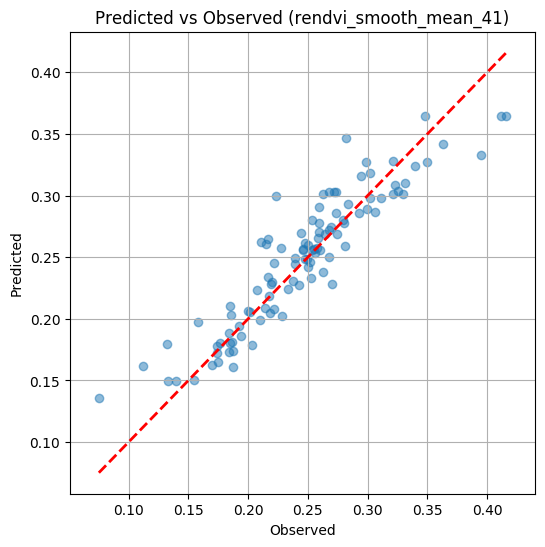

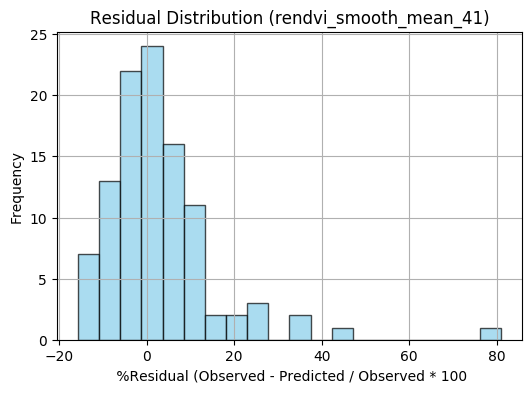

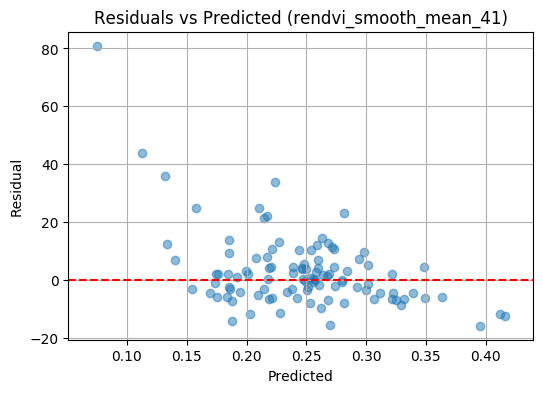

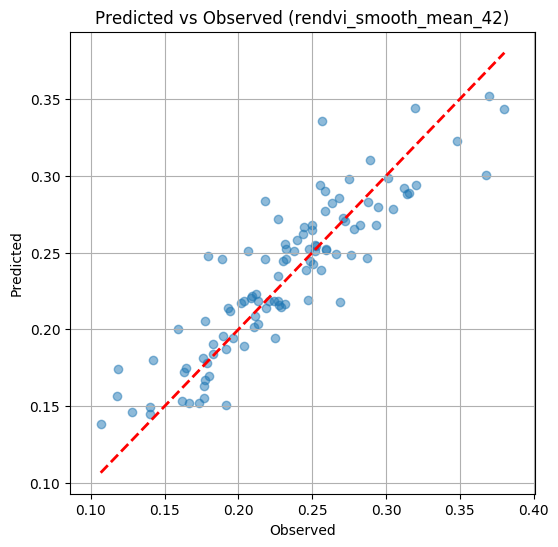

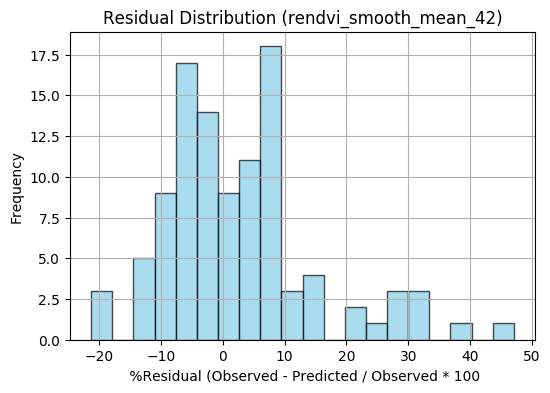

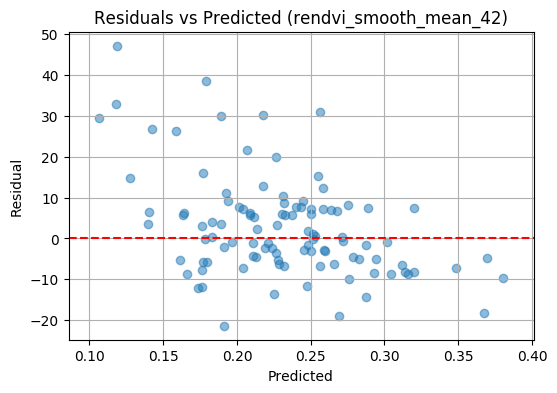

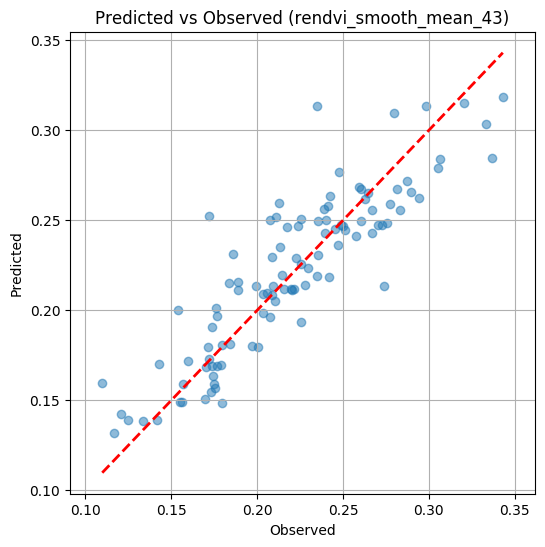

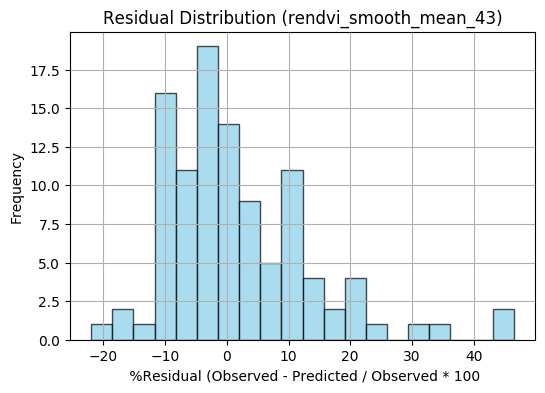

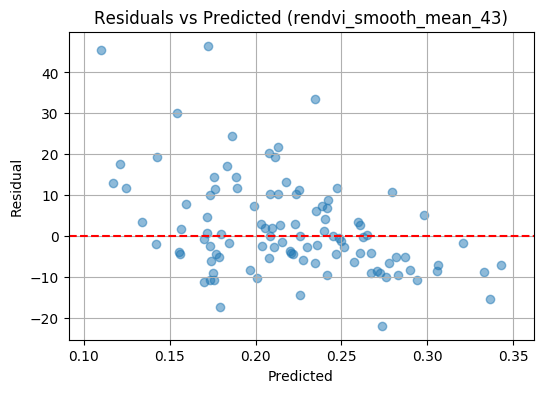

In [16]:
# --------------------------
# Visualization (all targets)
# --------------------------
for i, col in enumerate(y.columns):
    obs = y_test.iloc[:, i].values
    pred = y_pred[:, i]
    residuals = (pred - obs) / obs * 100

    # Predicted vs Observed
    plt.figure(figsize=(6,6))
    plt.scatter(obs, pred, alpha=0.5)
    plt.plot([obs.min(), obs.max()],
             [obs.min(), obs.max()],
             'r--', lw=2)
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(f"Predicted vs Observed ({col})")
    plt.grid(True)
    plt.show()

    # Residuals distribution
    plt.figure(figsize=(6,4))
    plt.hist(residuals, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.xlabel(" %Residual (Observed - Predicted / Observed * 100")
    plt.ylabel("Frequency")
    plt.title(f"Residual Distribution ({col})")
    plt.grid(True)
    plt.show()

    # Residuals vs Predicted
    plt.figure(figsize=(6,4))
    plt.scatter(obs, residuals, alpha=0.5)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(f"Residuals vs Predicted ({col})")
    plt.grid(True)
    plt.show()